# 03 · Conversation → Published: what drives a successful video?

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from data_science.features import _intent_features, _anatomy_features, _text_features
from data_science.modeling import evaluate_classifier, odds_ratio_table
from data_science import visualisation as vis

# GLOBAL VARIABLES
from nlp.paths import PROCESSED
TARGET = "published"

NUMERIC_FEATURES = [
    "num_user_messages", "conversation_duration_minutes", "avg_user_msg_len",
    "n_edits_content", "n_edits_visual", 
    "n_Dissatisfaction", 
    "intent_diversity",
    # "brief_completeness",
]

BINARY_FEATURES = [
    "has_approval", "has_dissatisfaction", 
]

CATEGORICAL_FEATURES = ['plan','opening_with_intent']

INTENTS = ["Create", "Edit content", "Edit visual", "Approval", "Dissatisfaction", "Other"]
ANATOMY_FLAGS = ["has_script", "has_avatar", "has_visual", "has_tone", "structured"]

In [2]:
def build_conversation_feature_table(data_source_directory=PROCESSED) -> pd.DataFrame:
    P = str(data_source_directory).rstrip("/") + "/"
    conv = pd.read_csv(P + "conversations.csv")
    msg = pd.read_csv(P + "messages.csv")
    intent = pd.read_csv(P + "user_messages_intent.csv")
    anat = pd.read_csv(P + "create_intent_messages_anatomy.csv")
    vid = pd.read_csv(P + "videos.csv")
    users = pd.read_csv(P + "users.csv")

    vid = vid.assign(published=vid["published_at"].notna().astype(int),
                     generated=vid["generated_at"].notna().astype(int))

    user_msgs = msg[msg["role"] == "user"].merge(intent[["message_id", "intent"]],
                                                 on="message_id", how="left")
    
    # generate and merge all features on conversation level
    df = (conv
          .merge(vid[["conversation_id", "published", "generated"]], on="conversation_id", how="left")
          .merge(_intent_features(user_msgs), on="conversation_id", how="left")
          .merge(_anatomy_features(anat, msg), on="conversation_id", how="left")
          .merge(_text_features(msg), on="conversation_id", how="left")
          .merge(users[["user_id", "plan"]], on="user_id", how="left"))

    # conversations with no Create message -> no brief
    for f in ANATOMY_FLAGS:
        df[f] = df[f].fillna(False).astype(bool)
    df["brief_completeness"] = df["brief_completeness"].fillna(0).astype(int)
    df["has_create_brief"] = df["has_create_brief"].fillna(False).astype(bool)

    # is_generated — control for the funnel gate (published ⊆ generated). Including it
    # showcases that "get a draft generated at all" is the biggest low-hanging fruit.
    df["is_generated"] = df["generated"].fillna(0).astype(int)

    # split a "Create" opening by brief completeness (>=4 is where publish rate jumps):
    # Create_complete = opened with a thorough brief, Create_vague = opened with a thin idea.
    is_create_open = df["opening_intent"] == "Create"
    df["opening_with_intent"] = df["opening_intent"].astype("object")
    df.loc[is_create_open, "opening_with_intent"] = np.where(
        df.loc[is_create_open, "brief_completeness"] >= 4, "Create_complete", "Create_vague")

    return df



In [3]:
conversation_features = build_conversation_feature_table()   # one row per conversation, from data/processed/
conversation_features = conversation_features[
    (conversation_features['opening_intent']!='Other')
    & (conversation_features['num_valid_assistant_messages'] >= 1) 
    & (conversation_features['num_valid_user_messages'] >= 1)
    & (conversation_features['num_valid_user_messages'] >= 0.5 * conversation_features['num_user_messages'])
    & (conversation_features['generated']==1) # only conversations with videos being generated
].copy()
print("feature table:", conversation_features.shape)
conversation_features.head()

feature table: (1258, 37)


,user_id,conversation_id,video_id,conversation_started_at,conversation_finished_at,num_messages,num_user_messages,num_assistant_messages,num_valid_user_messages,num_valid_assistant_messages,...,has_avatar,has_visual,has_tone,structured,brief_completeness,has_create_brief,avg_user_msg_len,plan,is_generated,opening_with_intent
0,usr_009ddeb9,conv_03cf567979,vid_bce2536d0a,2024-06-03 04:50:57,2024-06-03 04:57:39,4,2,2,2,2,...,False,False,False,False,0,True,37.500000,growth,1,Create_vague
1,usr_009ddeb9,conv_1227413fa7,vid_ac0e078db7,2024-12-05 23:27:37,2024-12-05 23:36:25,6,3,3,3,3,...,False,False,False,False,0,True,43.000000,growth,1,Create_vague
2,usr_009ddeb9,conv_136000d810,vid_dac286dccc,2024-06-13 05:51:35,2024-06-13 06:09:07,10,5,5,5,5,...,False,False,False,False,0,False,39.800000,growth,1,Edit visual
3,usr_009ddeb9,conv_1e44eb53f3,vid_8a93103ed7,2025-02-15 22:47:43,2025-02-15 23:03:15,6,3,3,3,3,...,False,False,False,False,1,True,83.333333,growth,1,Create_vague
5,usr_009ddeb9,conv_6188a52667,vid_a9cca9342d,2024-06-01 13:28:54,2024-06-01 13:39:08,6,3,3,3,3,...,False,False,False,False,1,True,79.333333,growth,1,Create_vague


## 1. Target & funnel base rates

`published` is the target. `generated` is kept as a secondary funnel signal (a draft was produced at all).

In [4]:
print(f"conversations         : {len(conversation_features):,}")
print(f"published base rate   : {conversation_features[TARGET].mean():.1%}")
print(f"generated rate        : {conversation_features['generated'].mean():.1%}")
print(f"published | generated : {conversation_features.loc[conversation_features['generated']==1, TARGET].mean():.1%}")

conversations         : 1,258
published base rate   : 54.1%
generated rate        : 100.0%
published | generated : 54.1%


## 2. Univariate signal — brief completeness

The single clearest pattern: **publish rate rises with how complete the opening brief is.** (Completeness 0 includes conversations that opened without a Create brief.)

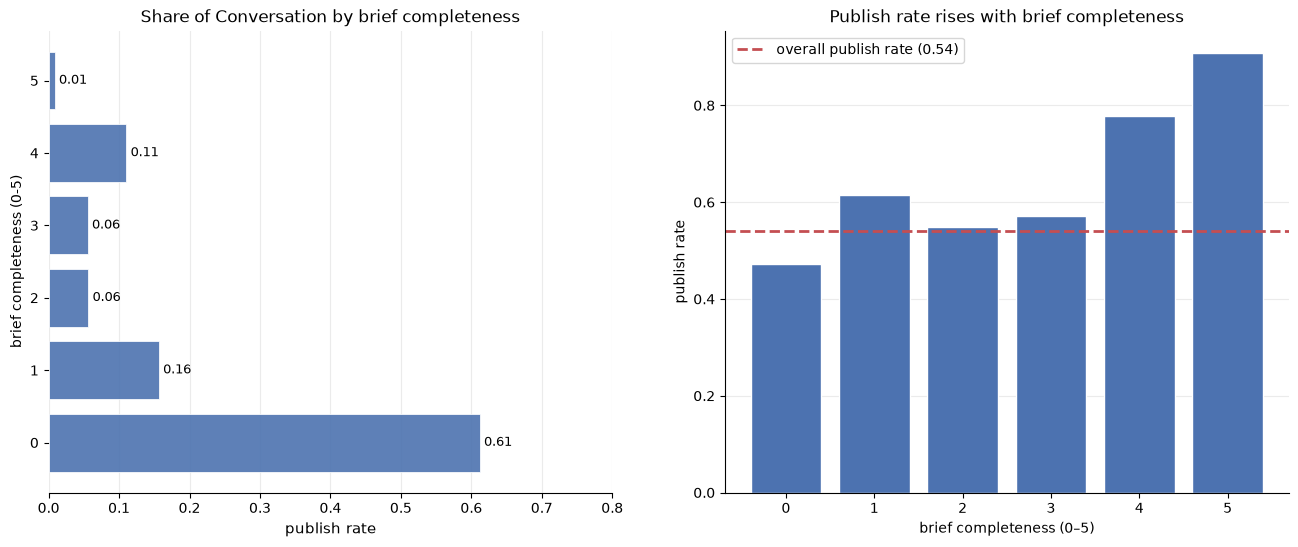

In [5]:
by_comp = conversation_features.groupby("brief_completeness")[TARGET].agg(["mean","count"])
by_comp['pct_count'] = by_comp['count'] / by_comp['count'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

vis.plot_barh(
    labels=by_comp.index.tolist(), values=by_comp['pct_count'], 
    sort=False, xlabel="publish rate",
    ax=ax1
)
ax1.set_xlim([0,0.8])
ax1.set_ylabel('brief completeness (0-5)')
ax1.set_title('Share of Conversation by brief completeness')

ax2.bar(by_comp.index, by_comp["mean"], color="#4C72B0", edgecolor="white")
publish_rate = conversation_features[TARGET].mean()
ax2.axhline(publish_rate, color="#C44E52", ls="--", lw=2, label="overall publish rate ({:.2f})".format(publish_rate))
ax2.set(xlabel="brief completeness (0–5)", ylabel="publish rate",
       title="Publish rate rises with brief completeness")
ax2.legend()
ax2.grid(axis="y", alpha=.25)
ax2.set_axisbelow(True)
sns.despine(ax=ax2, left=False)
plt.show()

## 3. Which brief element matters?

Among conversations that *have* a Create brief, publish rate with vs. without each element. **Script, avatar and visual direction each roughly double publish rate; tone barely moves it.**

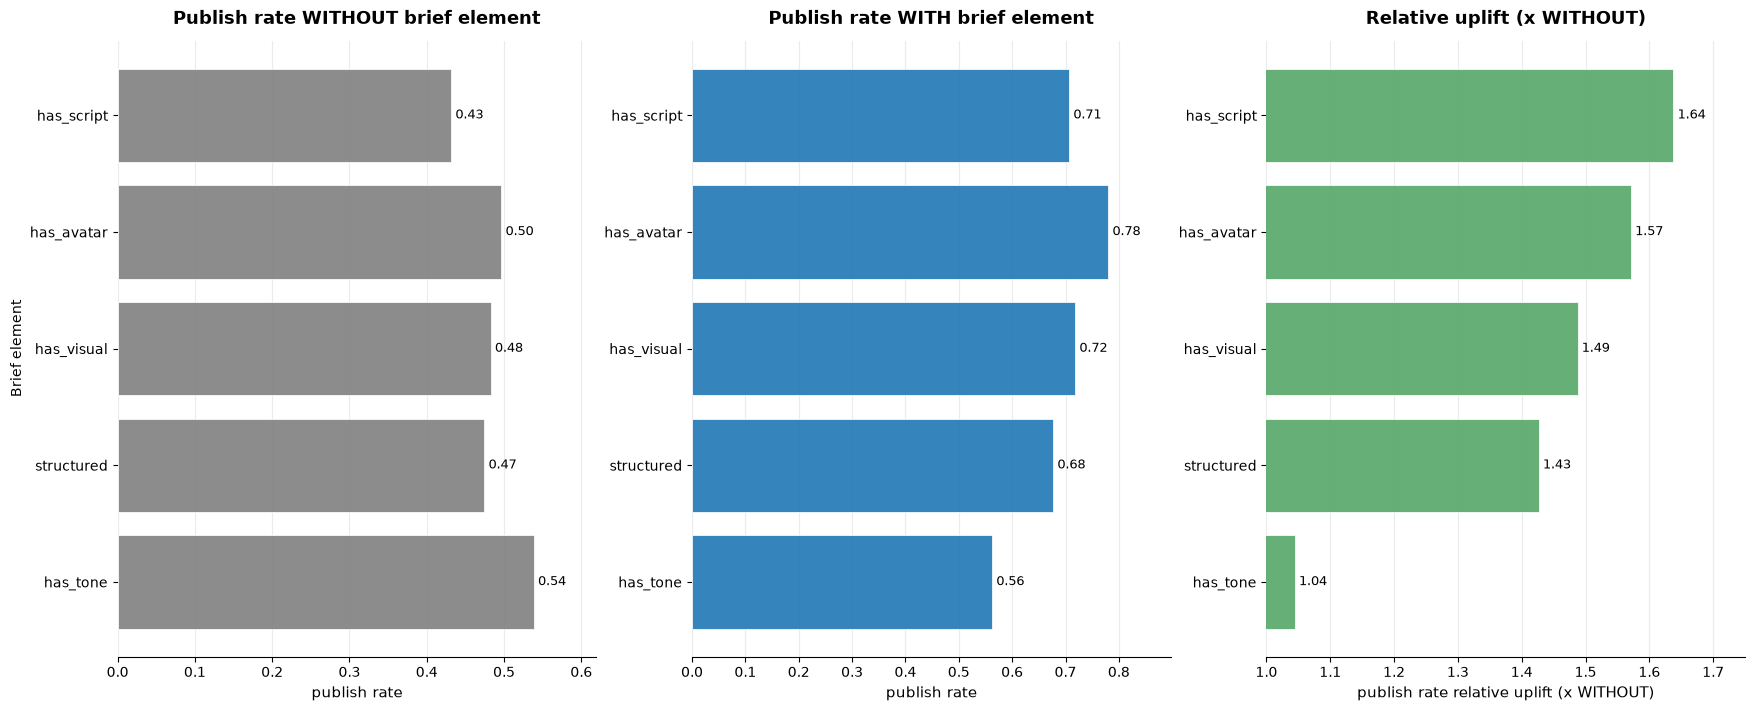

In [6]:
cwb = conversation_features[conversation_features["has_create_brief"]]
element_df = pd.DataFrame({f: {
    "without": cwb.loc[~cwb[f], TARGET].mean(),
    "with":    cwb.loc[cwb[f],  TARGET].mean()} for f in ANATOMY_FLAGS}).T

element_df["uplift"] = element_df["with"] / element_df["without"]
element_df = element_df.sort_values('uplift')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21,8))

vis.plot_barh(labels=element_df.index.tolist(), values=element_df['without'], sort=False, 
              color='gray', xlabel="publish rate", 
              title='Publish rate WITHOUT brief element', ax=ax1)

vis.plot_barh(labels=element_df.index.tolist(), values=element_df['with'], sort=False, 
              color='tab:blue', xlabel="publish rate", 
              title='Publish rate WITH brief element', ax=ax2)

vis.plot_barh(labels=element_df.index.tolist(), values=element_df['uplift'], sort=False, 
              color='#55A868', xlabel="publish rate relative uplift (x WITHOUT)", 
              title='Relative uplift (x WITHOUT)', ax=ax3)

ax1.set_ylabel('Brief element')
ax3.set_xlim([1, 1.75])

plt.show()

## 4. Model — OLS logistic regression


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X, y = conversation_features[NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES], conversation_features[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("bin", "passthrough", BINARY_FEATURES),
    ("cat", OneHotEncoder(drop=["starter", "Create_vague"], handle_unknown="ignore"), CATEGORICAL_FEATURES),
])
logit = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logit.fit(X_tr, y_tr)
_ = evaluate_classifier(y_te, logit.predict(X_te), logit.predict_proba(X_te)[:, 1])

              precision    recall  f1-score   support

           0       0.58      0.61      0.59       144
           1       0.65      0.62      0.64       171

    accuracy                           0.62       315
   macro avg       0.61      0.62      0.61       315
weighted avg       0.62      0.62      0.62       315

ROC-AUC : 0.636
PR-AUC  : 0.642  (base rate = 0.543)


(<Figure size 2000x2000 with 3 Axes>,
 <Axes: title={'center': 'other plans vs plan_starter'}, xlabel='effect'>)

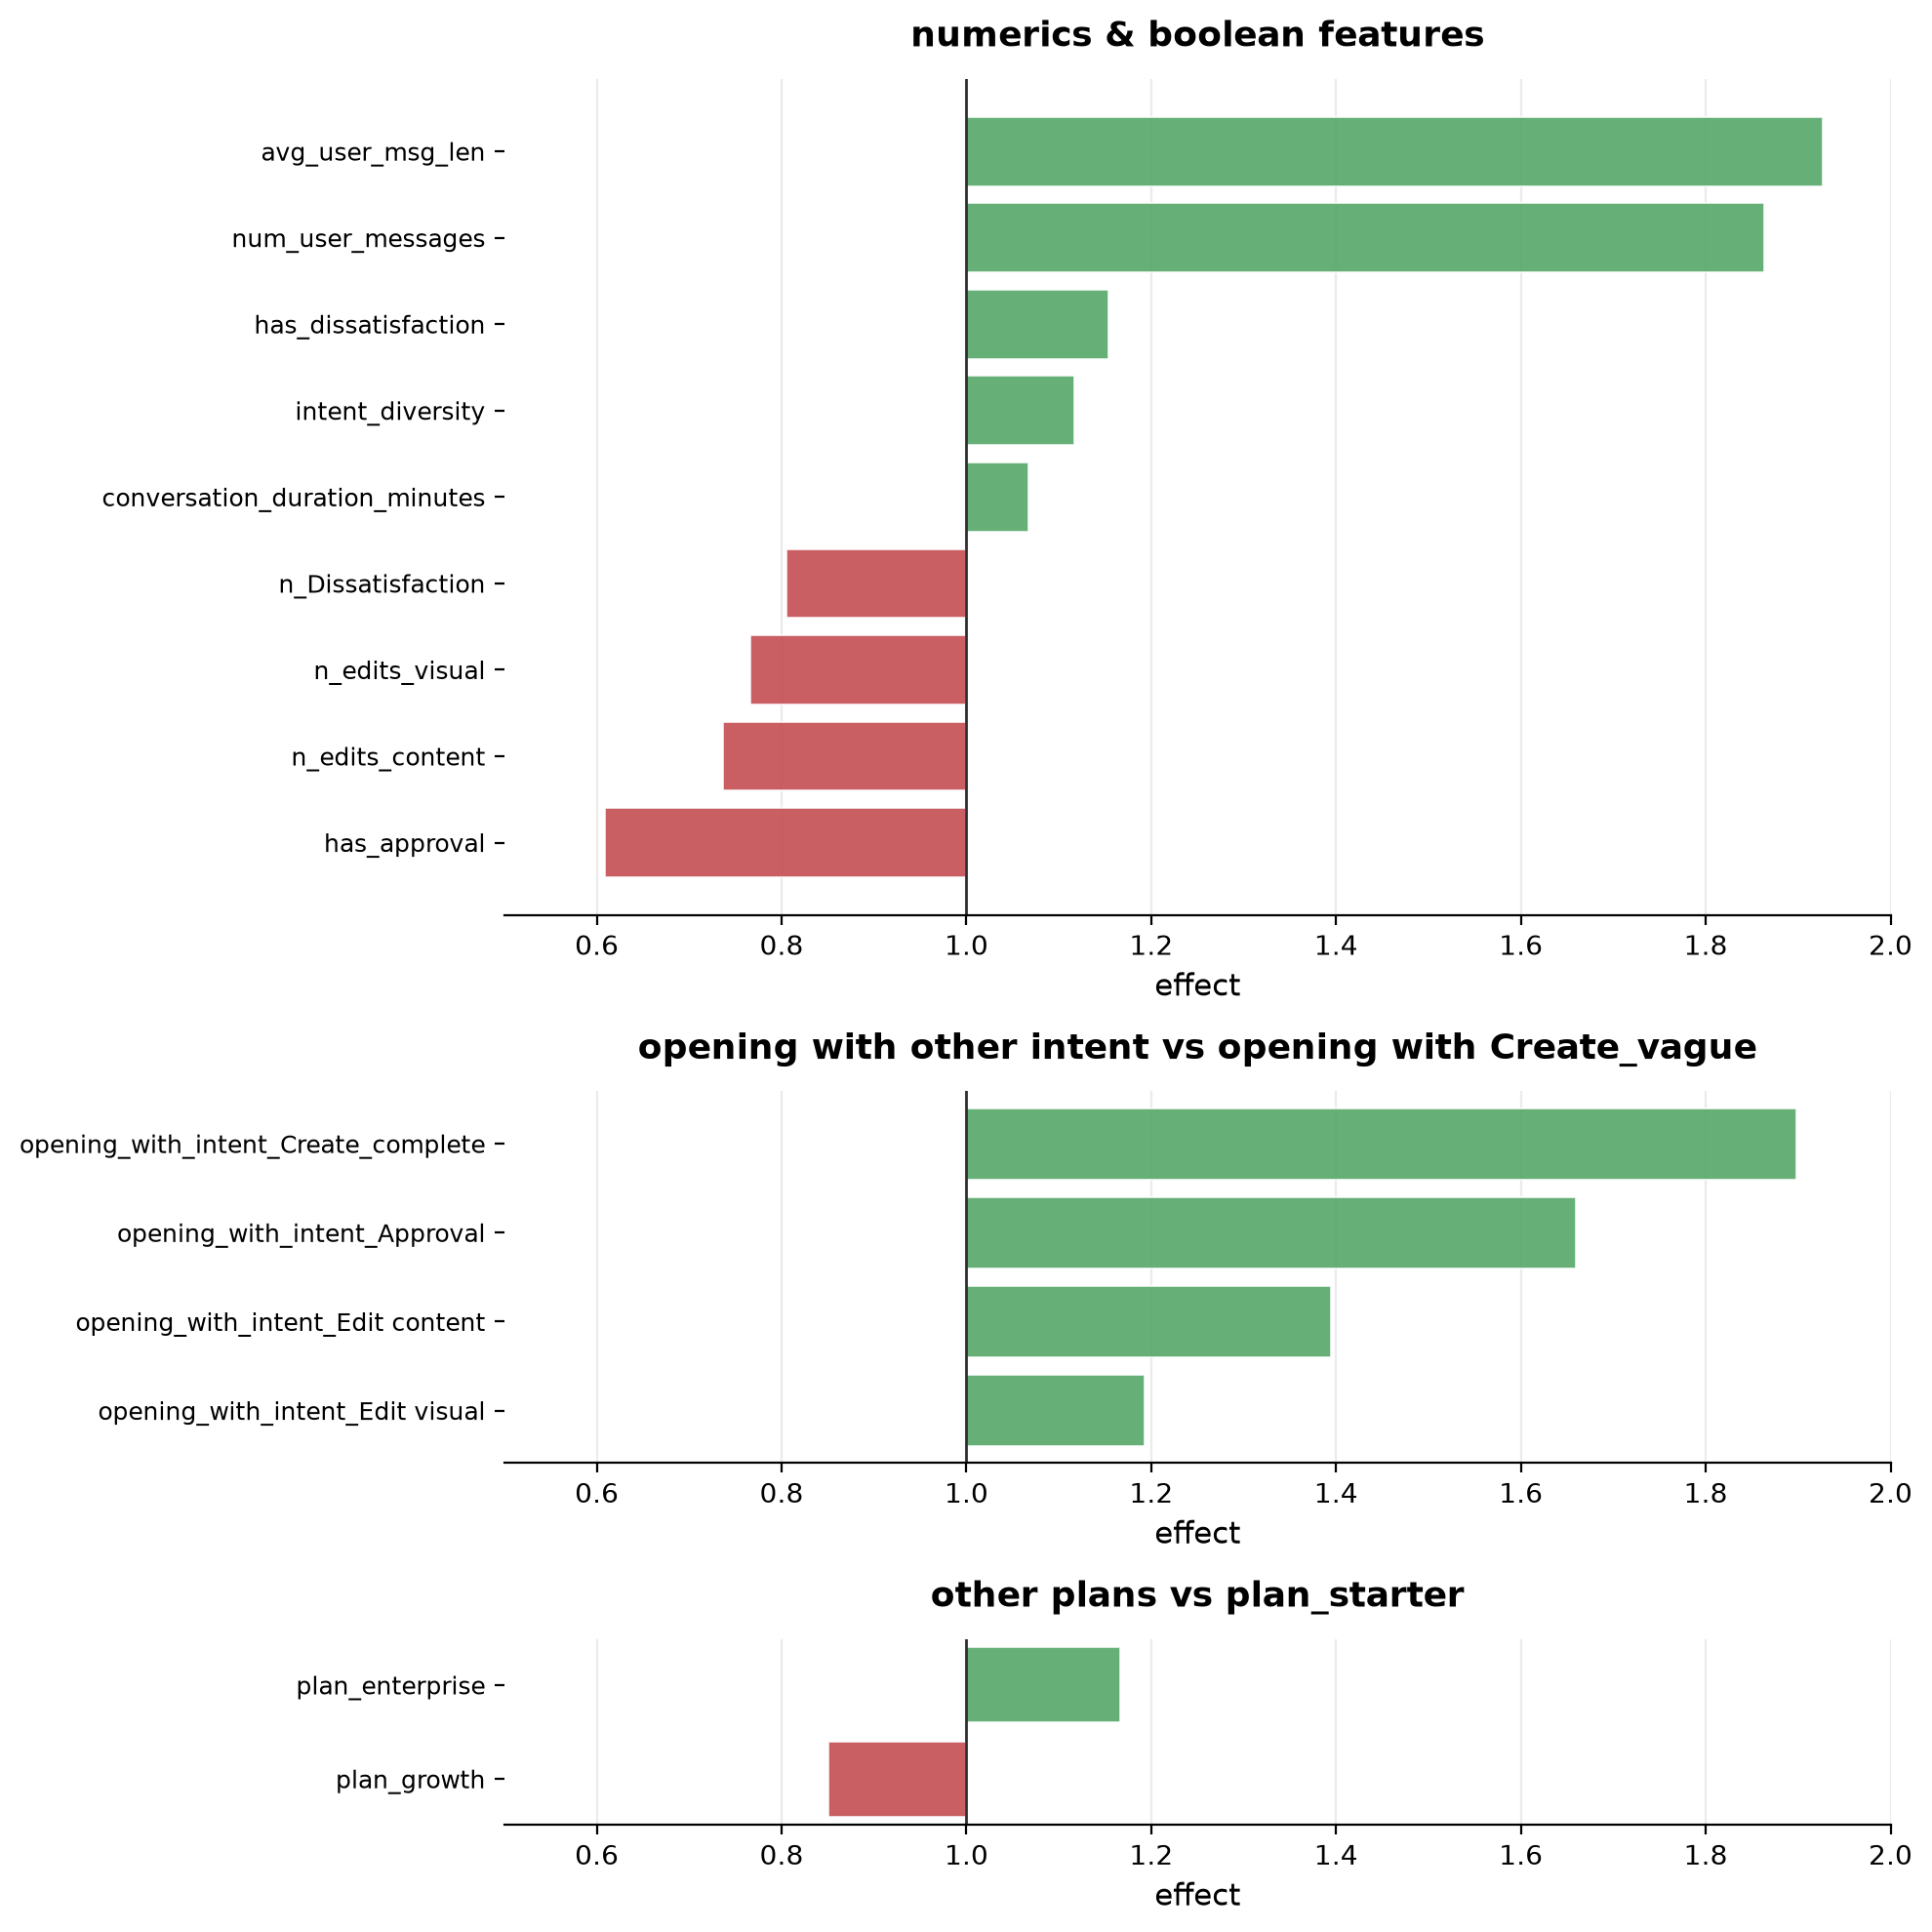

In [8]:
feature_names = (NUMERIC_FEATURES + BINARY_FEATURES + 
    list(logit.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES)))
feature_odd_ratios = odds_ratio_table(logit.named_steps["clf"], feature_names)

numeric_features_ors = feature_odd_ratios[feature_odd_ratios['feature'].isin(NUMERIC_FEATURES + BINARY_FEATURES)]
plan_features = feature_odd_ratios[feature_odd_ratios['feature'].isin(['plan_growth', 'plan_enterprise'])]
opening_intent_features = (
    feature_odd_ratios[feature_odd_ratios['feature'].isin(
        ['opening_with_intent_Approval', 
         'opening_with_intent_Edit content', 
         'opening_with_intent_Edit visual', 
         'opening_with_intent_Create_complete'])])

fig, (ax1, ax2, ax3) = plt.subplots(ncols=1, nrows=3, figsize=(10,10), 
                                    dpi=200, tight_layout=True, 
                                    gridspec_kw={"height_ratios": [9, 4, 2]})

vis.plot_feature_effects(numeric_features_ors["feature"], 
                         numeric_features_ors["odds_ratio"].values, 
                         center=1.0, xlim=(0.5, 2.0),
                         title="numerics & boolean features", ax=ax1)

vis.plot_feature_effects(opening_intent_features["feature"], 
                         opening_intent_features["odds_ratio"].values, 
                         center=1.0, xlim=(0.5, 2.0),
                         title='opening with other intent vs opening with Create_vague', ax=ax2)

vis.plot_feature_effects(plan_features["feature"], 
                         plan_features["odds_ratio"].values, 
                         center=1.0, xlim=(0.5, 2.0),
                         title="other plans vs plan_starter", ax=ax3)

# plt.savefig('regression.png', dpi=300)

# End of notebook –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––